# DPT Pancreas — λ_vf Sweep Plotting

Data extracted from the completed HPC run `dpt_pancreas_vf_sweep_20260528_131011`.  
All 5 seeds completed fully.  
λ_lap fixed at 100. λ_vf swept over 9 values: `np.logspace(0, 4.0, 9)`.  
Epochs logged every 10 steps; epoch 140 used as proxy for epoch 150 (final).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# λ_vf values — np.logspace(0, 4.0, 9)
LAMBDA_VFS = np.logspace(0, 4.0, 9)
print('lambda_vf values:', np.round(LAMBDA_VFS, 4))

lambda_vf values: [1.0000000e+00 3.1623000e+00 1.0000000e+01 3.1622800e+01 1.0000000e+02
 3.1622780e+02 1.0000000e+03 3.1622777e+03 1.0000000e+04]


In [2]:
# ---------------------------------------------------------------------------
# Raw data: r values logged every 10 epochs (i=0,10,...,140)
# Shape: [seed, lambda_idx, epoch_idx]  where epoch_idx ∈ {0,...,14} → epochs 0,10,...,140
# All 5 seeds × 9 lambda values × 15 logged checkpoints — no missing data
# Seeds: 6, 7, 8, 9, 10
# ---------------------------------------------------------------------------

EPOCHS_LOGGED = list(range(0, 141, 10))  # 0, 10, ..., 140

# Each row = one lambda_vf, each column = one logged epoch
seed6 = np.array([
    # lv=1.00e+00
    [-0.124, 0.234, 0.202, 0.157, 0.190, 0.194, 0.334, 0.407, 0.449, 0.459, 0.467, 0.466, 0.462, 0.458, 0.455],
    # lv=3.16e+00
    [0.585, 0.608, 0.416, 0.268, 0.296, 0.259, 0.248, 0.249, 0.231, 0.217, 0.197, 0.187, 0.183, 0.189, 0.201],
    # lv=1.00e+01
    [0.248, 0.152, 0.226, 0.210, 0.155, 0.154, 0.182, 0.197, 0.190, 0.189, 0.187, 0.185, 0.186, 0.183, 0.193],
    # lv=3.16e+01
    [0.317, 0.085, 0.025, 0.026, 0.016, -0.062, -0.086, -0.083, 0.184, 0.183, 0.193, 0.195, 0.193, 0.185, 0.171],
    # lv=1.00e+02
    [0.502, 0.114, 0.101, 0.003, 0.044, 0.026, -0.024, -0.045, -0.059, -0.048, 0.001, 0.032, 0.098, 0.241, 0.281],
    # lv=3.16e+02
    [0.034, 0.466, 0.442, 0.444, 0.491, 0.499, 0.487, 0.490, 0.489, 0.488, 0.500, 0.500, 0.502, 0.505, 0.496],
    # lv=1.00e+03
    [0.065, -0.007, -0.178, -0.122, 0.082, 0.079, 0.101, 0.123, 0.126, 0.122, 0.113, 0.114, 0.090, 0.458, 0.470],
    # lv=3.16e+03
    [-0.102, 0.042, 0.334, 0.362, 0.257, 0.191, 0.310, 0.147, 0.042, 0.103, 0.166, 0.042, 0.340, 0.347, 0.018],
    # lv=1.00e+04
    [0.240, 0.506, 0.364, 0.080, -0.227, -0.033, -0.001, 0.261, 0.244, -0.041, 0.063, 0.162, 0.041, 0.259, 0.065],
])

seed7 = np.array([
    # lv=1.00e+00
    [-0.071, -0.127, -0.070, 0.050, 0.123, 0.062, 0.037, 0.019, 0.008, -0.014, -0.034, -0.033, -0.022, -0.007, 0.008],
    # lv=3.16e+00
    [0.110, -0.027, 0.079, 0.034, 0.025, 0.032, 0.052, 0.097, 0.142, 0.166, 0.184, 0.193, 0.205, 0.223, 0.241],
    # lv=1.00e+01
    [0.270, -0.041, 0.016, 0.032, 0.075, 0.058, 0.064, 0.057, 0.054, 0.058, 0.058, 0.053, 0.052, -0.151, -0.156],
    # lv=3.16e+01
    [0.114, 0.442, 0.491, 0.368, 0.429, 0.443, 0.441, 0.442, 0.442, 0.440, 0.438, 0.436, 0.435, 0.436, 0.435],
    # lv=1.00e+02
    [0.163, 0.417, 0.420, 0.429, 0.305, 0.213, 0.170, 0.149, 0.135, 0.129, 0.127, 0.127, 0.127, 0.131, 0.141],
    # lv=3.16e+02
    [-0.019, 0.109, 0.079, 0.148, 0.181, 0.194, 0.204, 0.218, 0.213, 0.196, 0.147, 0.119, 0.115, -0.125, -0.026],
    # lv=1.00e+03
    [0.942, -0.033, 0.203, 0.164, 0.185, 0.133, 0.126, 0.111, 0.094, 0.083, 0.076, 0.073, 0.071, 0.072, 0.072],
    # lv=3.16e+03
    [-0.004, 0.510, 0.500, 0.474, 0.509, 0.515, 0.506, 0.499, 0.516, 0.701, 0.226, 0.196, 0.167, 0.065, -0.161],
    # lv=1.00e+04
    [0.329, 0.111, 0.276, 0.149, -0.064, 0.013, 0.151, 0.072, -0.243, -0.173, -0.011, -0.037, 0.113, 0.040, -0.013],
])

seed8 = np.array([
    # lv=1.00e+00
    [0.368, -0.114, -0.046, -0.017, 0.037, 0.011, -0.039, -0.082, -0.122, -0.116, -0.105, -0.095, -0.090, -0.089, -0.088],
    # lv=3.16e+00
    [0.519, 0.443, 0.205, 0.048, 0.029, 0.040, 0.039, 0.059, 0.065, 0.067, 0.082, 0.092, 0.081, 0.104, 0.123],
    # lv=1.00e+01
    [0.378, 0.174, -0.092, -0.079, -0.055, -0.046, -0.026, -0.014, 0.005, 0.030, 0.053, 0.076, 0.094, 0.110, 0.120],
    # lv=3.16e+01
    [-0.061, 0.144, 0.502, 0.782, 0.841, 0.758, 0.742, 0.586, 0.508, 0.471, 0.446, 0.425, 0.408, 0.394, 0.443],
    # lv=1.00e+02
    [0.199, 0.248, 0.185, 0.138, 0.108, 0.059, 0.026, 0.030, 0.030, 0.028, 0.013, -0.001, -0.008, -0.012, -0.007],
    # lv=3.16e+02
    [0.696, -0.170, 0.053, 0.058, 0.114, 0.160, 0.388, 0.420, 0.425, 0.426, 0.428, 0.429, 0.430, 0.431, 0.433],
    # lv=1.00e+03
    [0.090, 0.270, 0.011, -0.016, -0.000, 0.037, 0.004, 0.029, 0.103, -0.029, -0.066, -0.083, -0.094, -0.101, -0.107],
    # lv=3.16e+03
    [0.957, -0.002, 0.212, 0.214, 0.165, 0.209, -0.036, 0.298, 0.101, 0.039, -0.012, 0.083, 0.008, 0.119, 0.031],
    # lv=1.00e+04
    [0.064, -0.040, 0.153, 0.114, 0.105, 0.088, 0.108, 0.171, 0.210, 0.189, 0.140, 0.112, 0.111, -0.029, 0.402],
])

seed9 = np.array([
    # lv=1.00e+00
    [0.172, -0.235, -0.191, -0.225, -0.255, -0.257, -0.270, -0.273, -0.273, -0.265, -0.251, -0.241, -0.237, -0.236, -0.228],
    # lv=3.16e+00
    [0.250, -0.132, 0.258, 0.273, 0.213, 0.207, 0.197, 0.219, 0.196, 0.215, 0.209, 0.200, 0.178, 0.155, 0.143],
    # lv=1.00e+01
    [0.159, 0.398, 0.424, 0.158, 0.179, 0.197, 0.191, 0.155, 0.156, 0.179, 0.195, 0.201, 0.199, 0.197, 0.195],
    # lv=3.16e+01
    [0.111, -0.198, -0.215, -0.191, -0.147, -0.111, -0.091, -0.082, -0.085, -0.081, -0.071, -0.064, -0.059, -0.056, -0.056],
    # lv=1.00e+02
    [-0.014, 0.227, -0.059, 0.079, 0.283, 0.410, 0.451, 0.435, 0.436, 0.429, 0.432, 0.440, 0.395, 0.436, 0.450],
    # lv=3.16e+02
    [0.405, 0.424, 0.463, 0.493, 0.503, 0.498, 0.511, 0.513, 0.508, 0.530, 0.528, 0.178, 0.055, 0.086, 0.003],
    # lv=1.00e+03
    [0.265, 0.206, 0.268, 0.243, 0.266, 0.260, 0.302, 0.392, 0.523, 0.725, 0.492, -0.041, 0.256, 0.119, 0.015],
    # lv=3.16e+03
    [0.266, 0.102, 0.091, 0.133, 0.104, 0.080, 0.047, 0.026, -0.026, -0.148, -0.004, -0.364, -0.190, -0.166, -0.039],
    # lv=1.00e+04
    [-0.064, -0.206, 0.172, 0.352, -0.139, 0.028, 0.034, 0.112, 0.050, 0.033, 0.034, 0.033, 0.165, -0.089, 0.063],
])

seed10 = np.array([
    # lv=1.00e+00
    [0.376, 0.157, 0.139, 0.160, 0.159, 0.162, 0.139, 0.159, 0.198, 0.257, 0.305, 0.327, 0.336, 0.341, 0.351],
    # lv=3.16e+00
    [0.200, 0.017, -0.012, -0.104, -0.132, -0.110, -0.099, -0.075, -0.058, -0.052, -0.049, -0.047, -0.046, -0.050, -0.056],
    # lv=1.00e+01
    [0.419, 0.821, 0.256, 0.480, 0.440, 0.356, 0.704, 0.705, 0.670, 0.592, 0.843, 0.862, 0.862, 0.855, 0.847],
    # lv=3.16e+01
    [0.448, 0.203, 0.127, 0.158, 0.161, 0.139, 0.130, 0.122, 0.113, 0.093, 0.087, 0.079, 0.046, 0.016, -0.006],
    # lv=1.00e+02
    [0.194, 0.095, 0.015, 0.025, -0.009, -0.008, -0.033, -0.055, -0.063, -0.065, -0.062, -0.056, -0.043, 0.007, 0.141],
    # lv=3.16e+02
    [-0.030, 0.405, 0.220, 0.303, 0.342, 0.338, 0.365, 0.360, 0.330, 0.291, 0.259, 0.352, 0.446, 0.452, 0.408],
    # lv=1.00e+03
    [0.109, 0.313, 0.343, 0.551, 0.586, 0.617, 0.642, 0.619, 0.543, 0.339, 0.155, 0.235, 0.052, -0.029, -0.004],
    # lv=3.16e+03
    [0.284, 0.315, 0.171, 0.156, 0.219, 0.247, 0.284, 0.466, 0.129, -0.122, 0.172, -0.020, -0.161, -0.038, 0.009],
    # lv=1.00e+04
    [0.257, 0.106, 0.133, 0.142, 0.076, 0.161, 0.067, 0.240, 0.164, 0.227, 0.136, -0.073, 0.090, -0.068, 0.144],
])

# Stack: shape (5, 9, 15)  — seeds × lambdas × logged_epochs
all_seeds = np.stack([seed6, seed7, seed8, seed9, seed10], axis=0)
print('all_seeds shape:', all_seeds.shape)  # (5, 9, 15)

all_seeds shape: (5, 9, 15)


In [3]:
# ---------------------------------------------------------------------------
# Summary: r at epoch ~50 (idx 5), ~100 (idx 10), ~140 (idx 14)
# Using logged epochs 50, 100, 140 as proxies for script checkpoints 50, 100, 150
# ---------------------------------------------------------------------------

EPOCH_IDX = {'~50': 5, '~100': 10, '~140': 14}

summary = {}
for label, eidx in EPOCH_IDX.items():
    vals = all_seeds[:, :, eidx]  # (5, 9)
    summary[label] = {
        'mean': np.nanmean(vals, axis=0),
        'std':  np.nanstd(vals, axis=0),
        'per_seed': vals,
    }

df_summary = pd.DataFrame({
    'lambda_vf': LAMBDA_VFS,
    'ep50_mean':  summary['~50']['mean'],
    'ep50_std':   summary['~50']['std'],
    'ep100_mean': summary['~100']['mean'],
    'ep100_std':  summary['~100']['std'],
    'ep140_mean': summary['~140']['mean'],
    'ep140_std':  summary['~140']['std'],
})
df_summary

,lambda_vf,ep50_mean,ep50_std,ep100_mean,ep100_std,ep140_mean,ep140_std
0,1.000000,0.0344,0.159986,0.0764,0.267249,0.0996,0.260928
1,3.162278,0.0856,0.132678,0.1246,0.097821,0.1304,0.102152
2,10.000000,0.1438,0.135166,0.2672,0.294223,0.2398,0.329818
3,31.622777,0.2334,0.326779,0.2186,0.200843,0.1974,0.211212
4,100.000000,0.1400,0.154719,0.1022,0.175808,0.2012,0.154185
5,316.227766,0.3378,0.144181,0.3724,0.146458,0.2628,0.225980
6,1000.000000,0.2252,0.209768,0.1540,0.184613,0.0892,0.198993
7,3162.277660,0.2484,0.144418,0.1096,0.098301,-0.0284,0.070392
8,10000.000000,0.0514,0.067078,0.0724,0.058538,0.1322,0.143749


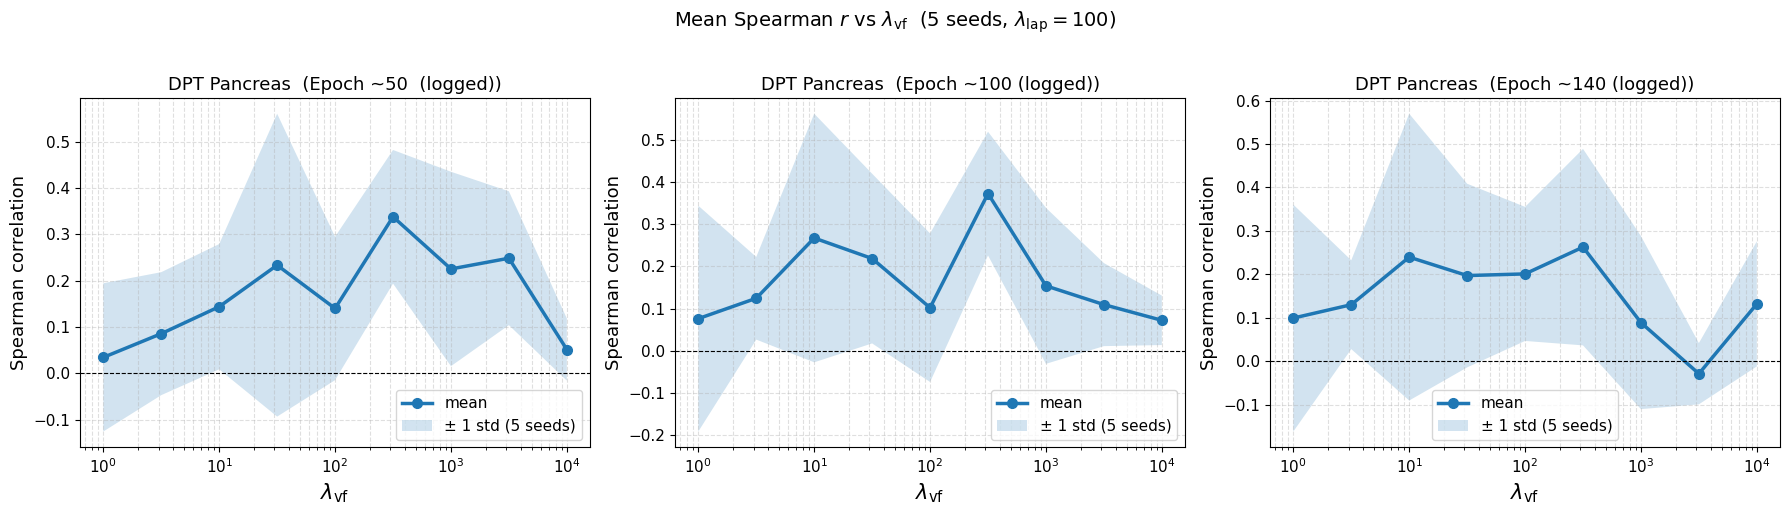

In [4]:
# ---------------------------------------------------------------------------
# Plot 1: Mean ± std across all 5 seeds — one panel per epoch checkpoint
# Matches the intended plot_correlation_vs_lambda_vf output
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50  (logged)',  axes[0]),
    ('~100', 'Epoch ~100 (logged)',  axes[1]),
    ('~140', 'Epoch ~140 (logged)',  axes[2]),
]

for label, title, ax in checkpoints:
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7, label='mean')
    ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2, label='± 1 std (5 seeds)')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
    ax.set_ylabel('Spearman correlation', fontsize=13)
    ax.set_title(f'DPT Pancreas  ({title})', fontsize=13)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)

plt.suptitle(
    r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (5 seeds, $\lambda_{\mathrm{lap}}=100$)',
    fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

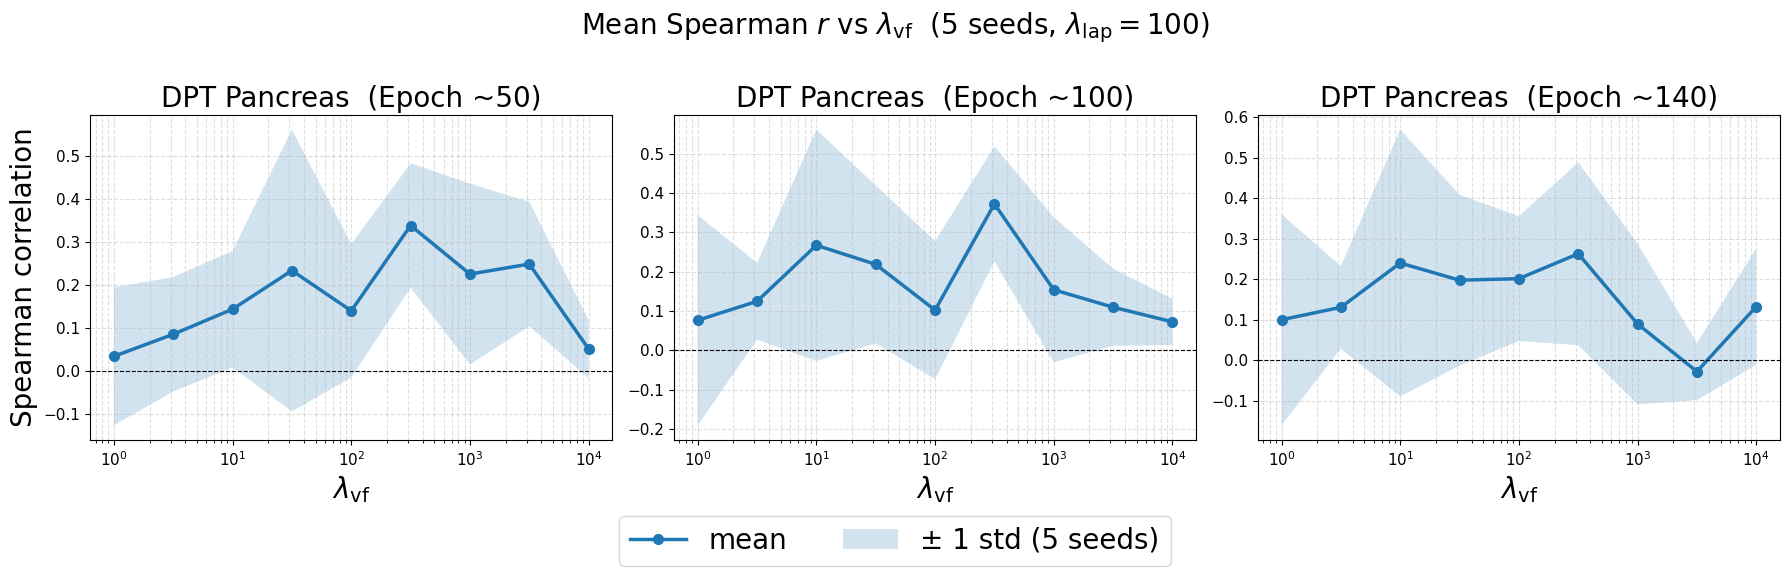

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50',  axes[0]),
    ('~100', 'Epoch ~100',  axes[1]),
    ('~140', 'Epoch ~140',  axes[2]),
]

handles_for_legend = None

for i, (label, title, ax) in enumerate(checkpoints):
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7, label='mean')
    ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2, label='± 1 std (5 seeds)')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=20)
    ax.set_title(f'DPT Pancreas  ({title})', fontsize=20)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)

    if i == 0:
        ax.set_ylabel('Spearman correlation', fontsize=20)
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()
    else:
        ax.set_ylabel('')

fig.legend(handles_for_legend, labels_for_legend, fontsize=20,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.12))

plt.suptitle(
    r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (5 seeds, $\lambda_{\mathrm{lap}}=100$)',
    fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

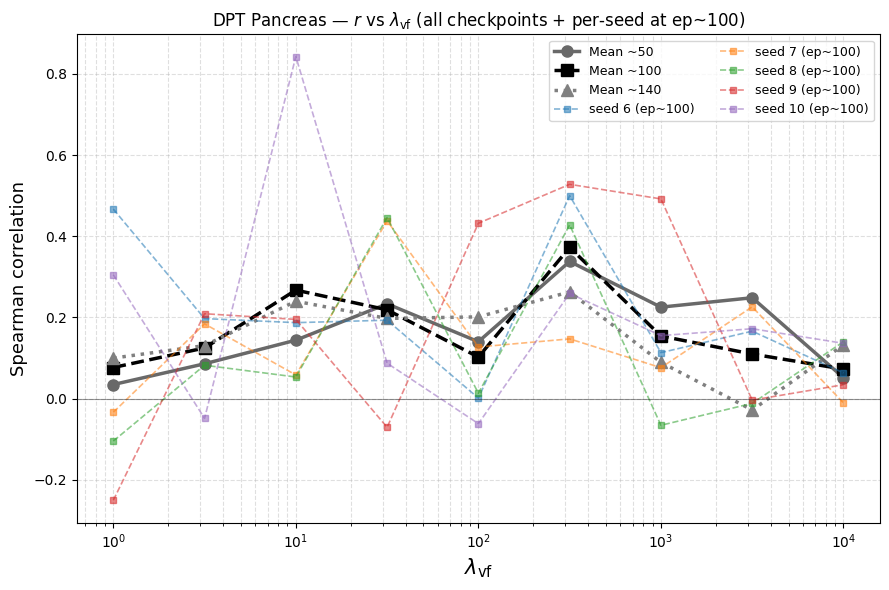

In [5]:
# ---------------------------------------------------------------------------
# Plot 2: Per-seed traces + mean — all three checkpoints overlaid
# ---------------------------------------------------------------------------

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
seed_labels = [f'seed {i}' for i in range(6, 11)]
checkpoint_styles = {'~50': ('o', '-'), '~100': ('s', '--'), '~140': ('^', ':')}

fig, ax = plt.subplots(figsize=(9, 6))

grays = {'~50': 'dimgray', '~100': 'black', '~140': 'gray'}
for label, (marker, ls) in checkpoint_styles.items():
    mu = summary[label]['mean']
    ax.semilogx(LAMBDA_VFS, mu, marker=marker, linestyle=ls,
                linewidth=2.5, markersize=8, label=f'Mean {label}',
                color=grays[label])

# Individual seeds at epoch ~100
for s_idx, (color, slabel) in enumerate(zip(seed_colors, seed_labels)):
    vals = all_seeds[s_idx, :, EPOCH_IDX['~100']]
    ax.semilogx(LAMBDA_VFS, vals, marker='s', linestyle='--',
                linewidth=1.2, markersize=5, alpha=0.55, color=color, label=f'{slabel} (ep~100)')

ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title(r'DPT Pancreas — $r$ vs $\lambda_{\mathrm{vf}}$ (all checkpoints + per-seed at ep~100)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

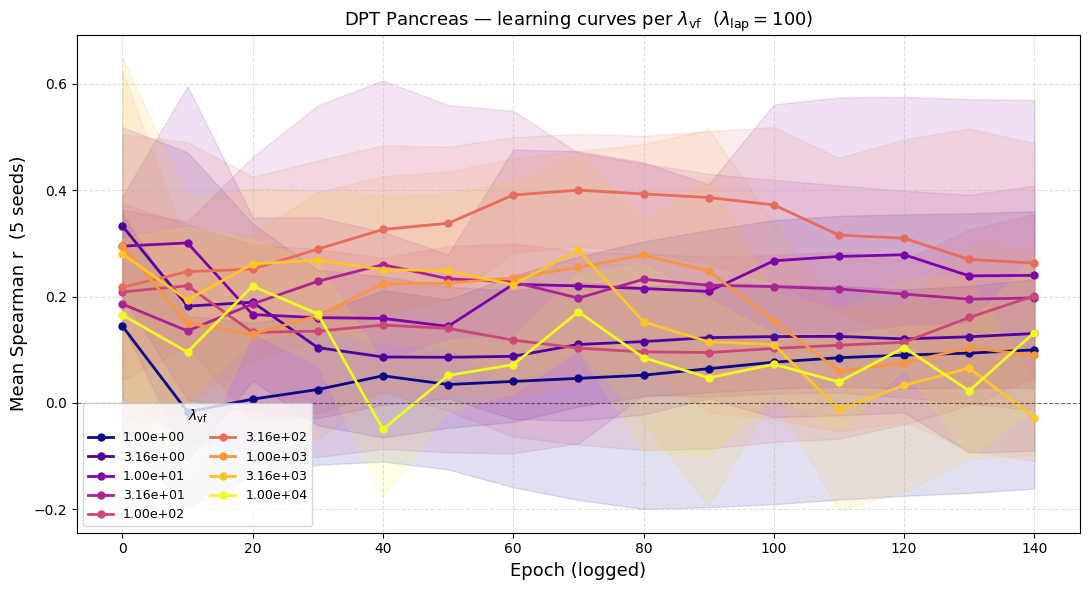

In [6]:
# ---------------------------------------------------------------------------
# Plot 3: Learning curves (r vs epoch) — mean across 5 seeds per λ_vf
# ---------------------------------------------------------------------------

epochs_arr = np.array(EPOCHS_LOGGED)
mean_curves = np.nanmean(all_seeds, axis=0)  # (9, 15)
std_curves  = np.nanstd(all_seeds, axis=0)

cmap = plt.cm.plasma
colors = [cmap(i / 8) for i in range(9)]

fig, ax = plt.subplots(figsize=(11, 6))
for lv_idx in range(9):
    lv_val = LAMBDA_VFS[lv_idx]
    mu = mean_curves[lv_idx]
    sig = std_curves[lv_idx]
    ax.plot(epochs_arr, mu, marker='o', markersize=5, linewidth=2.0,
            color=colors[lv_idx], label=f'{lv_val:.2e}')
    ax.fill_between(epochs_arr, mu - sig, mu + sig, alpha=0.12, color=colors[lv_idx])

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch (logged)', fontsize=13)
ax.set_ylabel('Mean Spearman r  (5 seeds)', fontsize=13)
ax.set_title(r'DPT Pancreas — learning curves per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=100$)', fontsize=13)
ax.legend(title=r'$\lambda_{\mathrm{vf}}$', fontsize=9, ncol=2,
          loc='lower left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

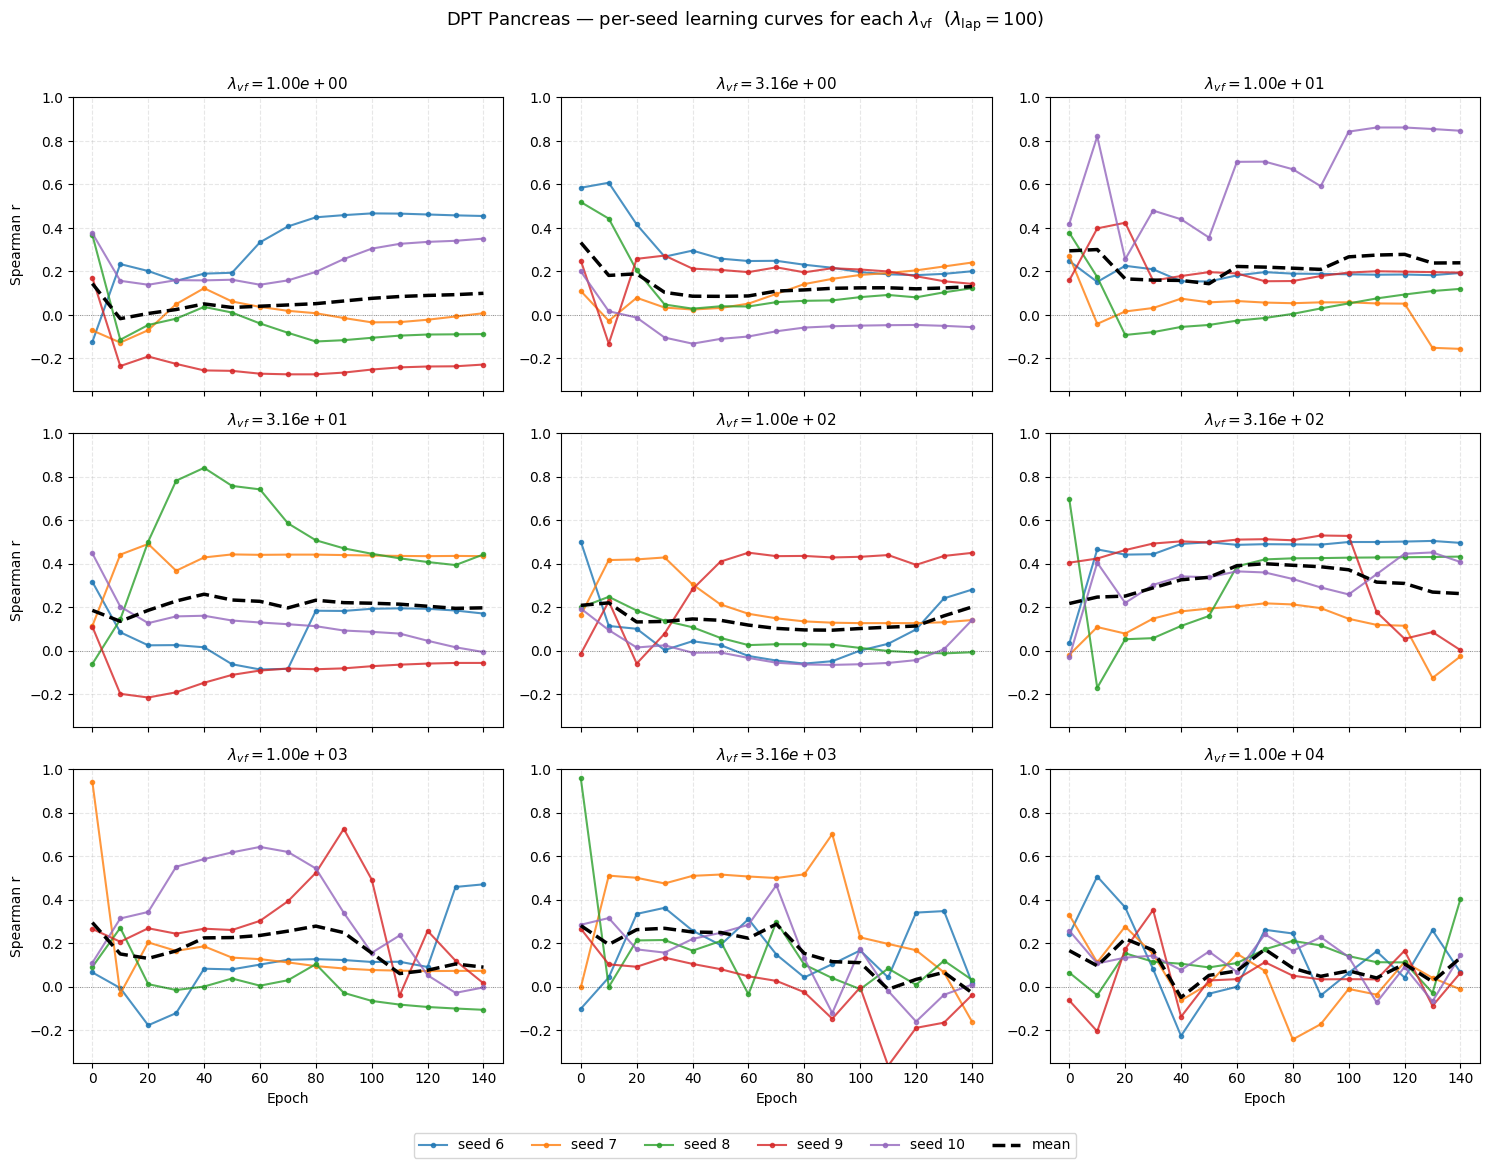

In [7]:
# ---------------------------------------------------------------------------
# Plot 4: Per-seed learning curves (small multiples) for each λ_vf
# 3×3 grid for 9 lambda values
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)

for lv_idx, ax in enumerate(axes.flat):
    lv_val = LAMBDA_VFS[lv_idx]
    for s_idx, (color, slabel) in enumerate(zip(seed_colors, seed_labels)):
        ax.plot(epochs_arr, all_seeds[s_idx, lv_idx, :],
                marker='o', markersize=3, linewidth=1.5,
                color=color, label=slabel, alpha=0.8)
    ax.plot(epochs_arr, mean_curves[lv_idx],
            color='black', linewidth=2.5, linestyle='--', label='mean')
    ax.axhline(0, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(rf'$\lambda_{{vf}}={lv_val:.2e}$', fontsize=11)
    ax.set_ylim(-0.35, 1.0)
    ax.grid(True, linestyle='--', alpha=0.3)
    if lv_idx % 3 == 0:
        ax.set_ylabel('Spearman r', fontsize=10)
    if lv_idx >= 6:
        ax.set_xlabel('Epoch', fontsize=10)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    r'DPT Pancreas — per-seed learning curves for each $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=100$)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vf_sweep_per_seed_grid.png', dpi=200, bbox_inches='tight')
plt.show()

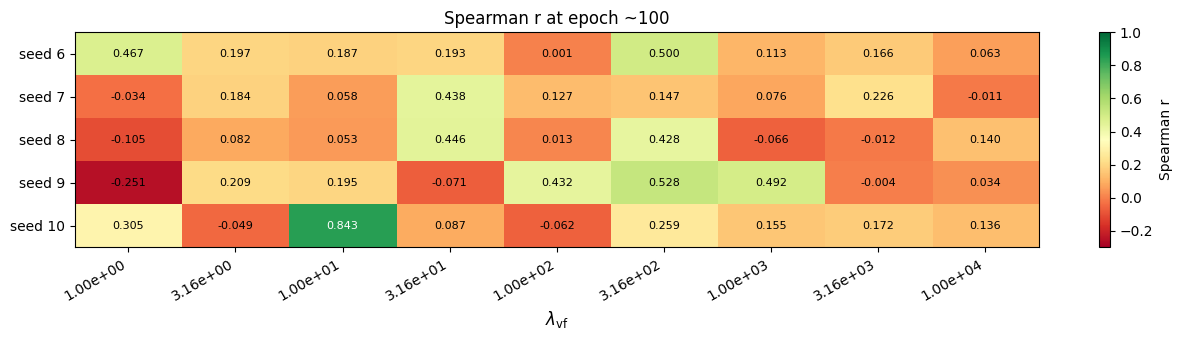

In [8]:
# ---------------------------------------------------------------------------
# Plot 5: Heatmap — r at epoch ~100 for all seeds × all λ_vf
# ---------------------------------------------------------------------------

r_ep100 = all_seeds[:, :, EPOCH_IDX['~100']]  # (5, 9)

fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(r_ep100, aspect='auto', cmap='RdYlGn', vmin=-0.3, vmax=1.0)
ax.set_xticks(range(9))
ax.set_xticklabels([f'{v:.2e}' for v in LAMBDA_VFS], rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels([f'seed {i}' for i in range(6, 11)])
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=12)
ax.set_title('Spearman r at epoch ~100', fontsize=12)
plt.colorbar(im, ax=ax, label='Spearman r')

for i in range(5):
    for j in range(9):
        val = r_ep100[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                color='black' if abs(val) < 0.7 else 'white')

plt.tight_layout()
plt.savefig('vf_sweep_heatmap_ep100.png', dpi=200, bbox_inches='tight')
plt.show()

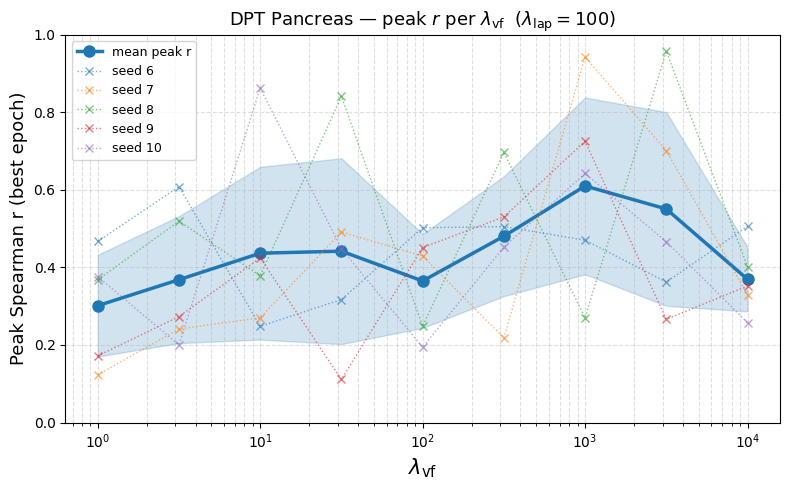

In [9]:
# ---------------------------------------------------------------------------
# Plot 6: Peak r achieved per (seed, lambda_vf) — shows best attainable r
# Useful since many runs diverge after their peak
# ---------------------------------------------------------------------------

peak_r = np.nanmax(all_seeds, axis=2)  # (5, 9) — max over epochs
mean_peak = peak_r.mean(axis=0)
std_peak  = peak_r.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(LAMBDA_VFS, mean_peak, marker='o', linewidth=2.5, markersize=8,
            color='tab:blue', label='mean peak r')
ax.fill_between(LAMBDA_VFS, mean_peak - std_peak, mean_peak + std_peak,
                alpha=0.2, color='tab:blue')

for s_idx, (color, slabel) in enumerate(zip(seed_colors, seed_labels)):
    ax.semilogx(LAMBDA_VFS, peak_r[s_idx], marker='x', linestyle=':',
                linewidth=1.0, markersize=6, alpha=0.6, color=color, label=slabel)

ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Peak Spearman r (best epoch)', fontsize=13)
ax.set_title(r'DPT Pancreas — peak $r$ per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=100$)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('vf_sweep_peak_r.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# ---------------------------------------------------------------------------
# Summary table — best λ_vf per checkpoint + peak r
# ---------------------------------------------------------------------------

print('Best lambda_vf by mean r (5 seeds):\n')
for label in ['~50', '~100', '~140']:
    mu = summary[label]['mean']
    best_idx = np.nanargmax(mu)
    print(f'  Epoch {label:5s}:  lambda_vf = {LAMBDA_VFS[best_idx]:.3e}  '
          f'→  mean r = {mu[best_idx]:.3f}  (std={summary[label]["std"][best_idx]:.3f})')

print()
best_peak_idx = np.argmax(mean_peak)
print(f'  Peak r:     lambda_vf = {LAMBDA_VFS[best_peak_idx]:.3e}  '
      f'→  mean peak r = {mean_peak[best_peak_idx]:.3f}  (std={std_peak[best_peak_idx]:.3f})')

print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))

Best lambda_vf by mean r (5 seeds):

  Epoch ~50  :  lambda_vf = 3.162e+02  →  mean r = 0.338  (std=0.144)
  Epoch ~100 :  lambda_vf = 3.162e+02  →  mean r = 0.372  (std=0.146)
  Epoch ~140 :  lambda_vf = 3.162e+02  →  mean r = 0.263  (std=0.226)

  Peak r:     lambda_vf = 1.000e+03  →  mean peak r = 0.610  (std=0.228)

 lambda_vf  ep50_mean  ep50_std  ep100_mean  ep100_std  ep140_mean  ep140_std
     1.000      0.034     0.160       0.076      0.267       0.100      0.261
     3.162      0.086     0.133       0.125      0.098       0.130      0.102
    10.000      0.144     0.135       0.267      0.294       0.240      0.330
    31.623      0.233     0.327       0.219      0.201       0.197      0.211
   100.000      0.140     0.155       0.102      0.176       0.201      0.154
   316.228      0.338     0.144       0.372      0.146       0.263      0.226
  1000.000      0.225     0.210       0.154      0.185       0.089      0.199
  3162.278      0.248     0.144       0.110      0.098